In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Superstore.csv')


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Sales          9994 non-null   float64
 16  Quantity       9994 non-null   int64  
 17  Discount       9994 non-null   float64
 18  Profit  

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')


In [10]:
aov = df['Sales'].sum() / df['Order ID'].nunique()
print(f"Average Order Value (AOV): ${aov:.2f}")

Average Order Value (AOV): $458.61


In [11]:
purchase_frequency = df.groupby('Customer ID')['Order ID'].nunique().mean()
print(f"Purchase Frequency: {purchase_frequency:.2f}")

Purchase Frequency: 6.32


In [12]:
customer_lifespan = df.groupby('Customer ID')['Order Date'].agg(['min', 'max'])
customer_lifespan['lifespan_days'] = (customer_lifespan['max'] - customer_lifespan['min']).dt.days
avg_customer_lifespan = customer_lifespan['lifespan_days'].mean() / 365
print(f"Average Customer Lifespan: {avg_customer_lifespan:.2f} years")

Average Customer Lifespan: 2.74 years


In [13]:
ltv = aov * purchase_frequency * avg_customer_lifespan

In [14]:
print(f"Customer Lifetime Value (LTV): ${ltv:.2f}")

Customer Lifetime Value (LTV): $7939.30


In [15]:
repeat_customers = df.groupby('Customer ID')['Order ID'].nunique().gt(1).sum()
total_customers = df['Customer ID'].nunique()
retention_rate_1 = (repeat_customers / total_customers) * 100
print(f"Retention Rate (Repeat Customers): {retention_rate_1:.2f}%")

Retention Rate (Repeat Customers): 98.49%


In [16]:
churn_rate = 100 - retention_rate_1
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 1.51%


In [17]:
monthly_orders = df.groupby([df['Order Date'].dt.to_period('M'), 'Customer ID'])['Order ID'].count().unstack().fillna(0)
cohort_retention = (monthly_orders.cumsum(axis=1) > 0).sum(axis=0) / total_customers * 100
print("Monthly Retention Rate:")
print(cohort_retention)

Monthly Retention Rate:
Customer ID
AA-10315    0.630517
AA-10375    1.765448
AA-10480    2.143758
AA-10645    2.648172
AB-10015    2.774275
              ...   
XP-21865    6.052963
YC-21895    6.052963
YS-21880    6.052963
ZC-21910    6.052963
ZD-21925    6.052963
Length: 793, dtype: float64


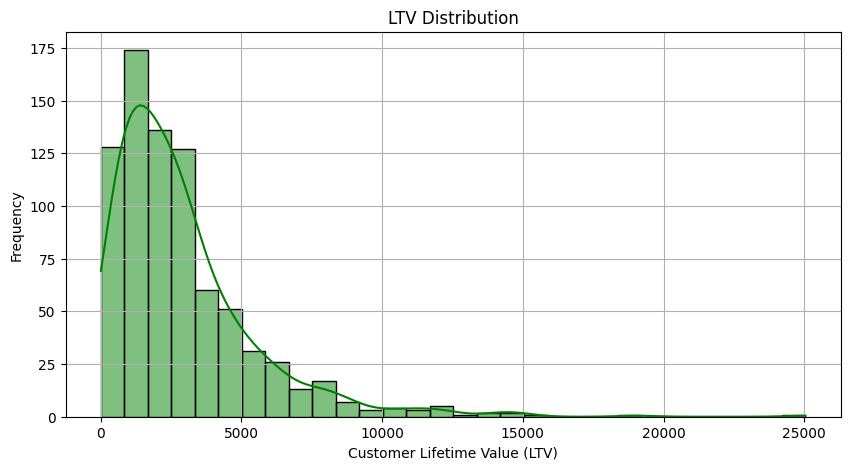

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df.groupby('Customer ID')['Sales'].sum(), bins=30, kde=True, color='green')
plt.xlabel('Customer Lifetime Value (LTV)')
plt.ylabel('Frequency')
plt.title('LTV Distribution')
plt.grid()
plt.show()

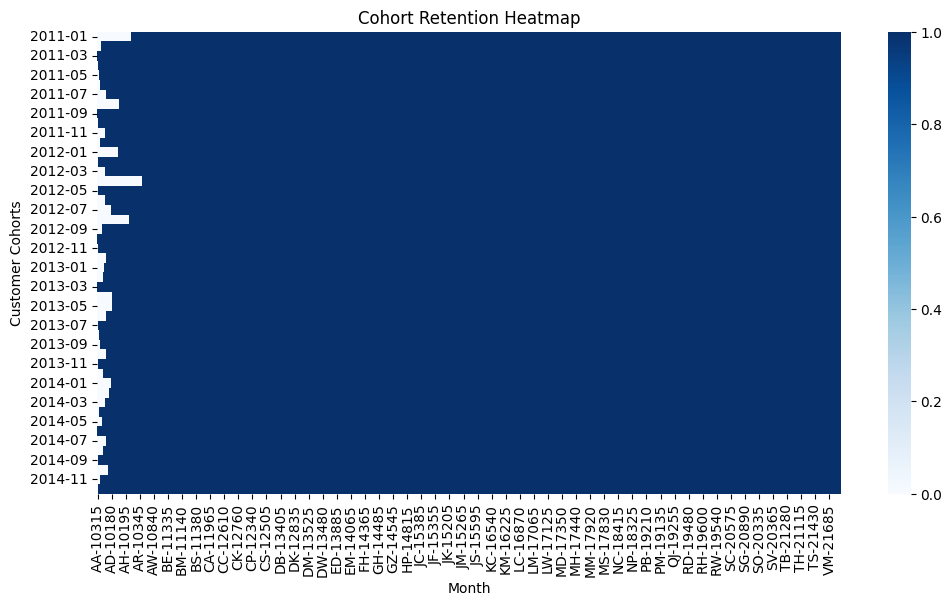

In [19]:
plt.figure(figsize=(12, 6))
sns.heatmap(monthly_orders.cumsum(axis=1) > 0, cmap='Blues', cbar=True)
plt.xlabel('Month')
plt.ylabel('Customer Cohorts')
plt.title('Cohort Retention Heatmap')
plt.show()

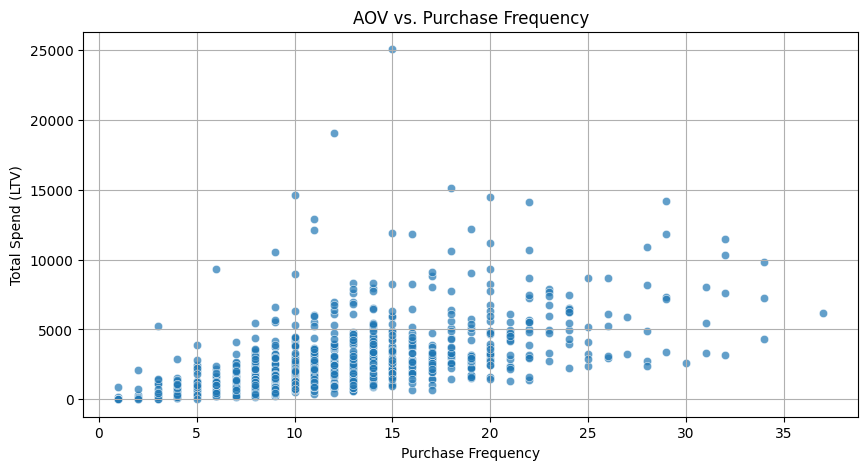

In [20]:
customer_data = df.groupby('Customer ID').agg({'Sales': 'sum', 'Order ID': 'count'})
plt.figure(figsize=(10, 5))
sns.scatterplot(x=customer_data['Order ID'], y=customer_data['Sales'], alpha=0.7)
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spend (LTV)')
plt.title('AOV vs. Purchase Frequency')
plt.grid()
plt.show()

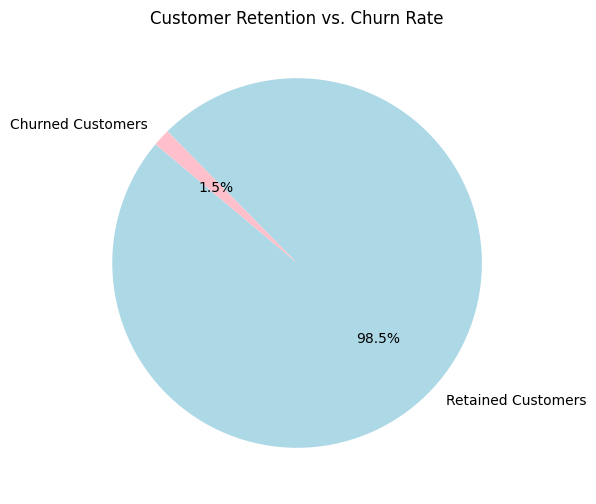

In [23]:
plt.figure(figsize=(6, 6))
labels = ['Retained Customers', 'Churned Customers']
sizes = [retention_rate_1, churn_rate]
colors = ['lightblue', 'pink']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Customer Retention vs. Churn Rate')
plt.show()

1. Increase customer retention by offering loyalty programs to repeat customers.
2. Focus marketing efforts on high-value customers based on their LTV.
3. Improve retention strategies in months with declining retention rates.
4. Analyze sales trends to optimize promotional campaigns for maximum impact.
